In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("anime.csv")

df.shape
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anime_id    10000 non-null  int64  
 1   title       10000 non-null  object 
 2   score       10000 non-null  float64
 3   rank        10000 non-null  int64  
 4   popularity  10000 non-null  int64  
 5   members     10000 non-null  int64  
 6   synopsis    9998 non-null   object 
 7   start_date  9998 non-null   object 
 8   end_date    9916 non-null   object 
 9   type        10000 non-null  object 
 10  episodes    9952 non-null   float64
 11  image_url   10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


anime_id       0
title          0
score          0
rank           0
popularity     0
members        0
synopsis       2
start_date     2
end_date      84
type           0
episodes      48
image_url      0
dtype: int64

In [3]:
df.duplicated().sum()

1

In [6]:
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce")

In [7]:
df["episodes"] = pd.to_numeric(df["episodes"], errors="coerce")

In [8]:
df["episodes"].fillna(df["episodes"].median(), inplace=True)
df["synopsis"].fillna("No description available", inplace=True)

In [12]:
df["release_year"] = df["release_year"].astype("Int64")
df["is_ongoing"] = df["end_date"].isnull().astype(int)

In [13]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   anime_id      10000 non-null  int64         
 1   title         10000 non-null  object        
 2   score         10000 non-null  float64       
 3   rank          10000 non-null  int64         
 4   popularity    10000 non-null  int64         
 5   members       10000 non-null  int64         
 6   synopsis      10000 non-null  object        
 7   start_date    9998 non-null   datetime64[ns]
 8   end_date      9916 non-null   datetime64[ns]
 9   type          10000 non-null  object        
 10  episodes      10000 non-null  float64       
 11  image_url     10000 non-null  object        
 12  release_year  9998 non-null   Int64         
 13  is_ongoing    10000 non-null  int32         
dtypes: Int64(1), datetime64[ns](2), float64(2), int32(1), int64(4), object(4)
memory usage:

In [14]:
df["score"].describe()
df["episodes"].describe()

count    10000.000000
mean        15.679700
std         41.766352
min          1.000000
25%          1.000000
50%         11.000000
75%         13.000000
max       1787.000000
Name: episodes, dtype: float64

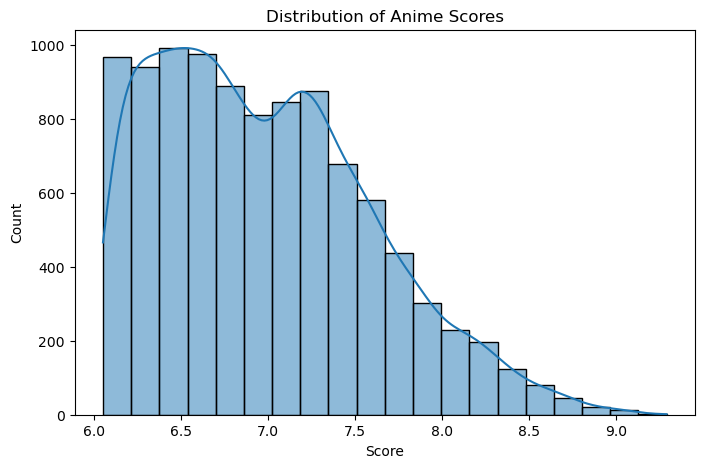

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["score"], bins=20, kde=True)
plt.title("Distribution of Anime Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

The score distribution is tightly clustered around a mean of 6.98, with most anime rated between 6.5 and 7.5. Extremely high-rated anime (>8.5) are rare, indicating a natural rating distribution with limited extreme values.

In [16]:
df["score"].describe()

count    10000.000000
mean         6.980589
std          0.619406
min          6.050000
25%          6.470000
50%          6.900000
75%          7.390000
max          9.290000
Name: score, dtype: float64

In [17]:
top_rated = df.sort_values(by="score", ascending=False)[
    ["title","score","rank","members"]
].head(10)

top_rated

,title,score,rank,members
3,Sousou no Frieren,9.29,1,1269074
1,Chainsaw Man Movie: Reze-hen,9.18,2,282129
10,Fullmetal Alchemist: Brotherhood,9.10,3,3602700
28,Steins;Gate,9.07,4,2755520
19,Kingdom 6th Season,9.06,5,25549
7,Shingeki no Kyojin Season 3 Part 2,9.05,6,2520232
0,Gintama°,9.05,8,680037
6,Gintama: The Final,9.05,7,177094
2,Hunter x Hunter (2011),9.03,9,3107455
23,One Piece Fan Letter,9.02,13,135168


In [18]:
df[["score","rank"]].corr()

,score,rank
score,1.000000,-0.976668
rank,-0.976668,1.000000


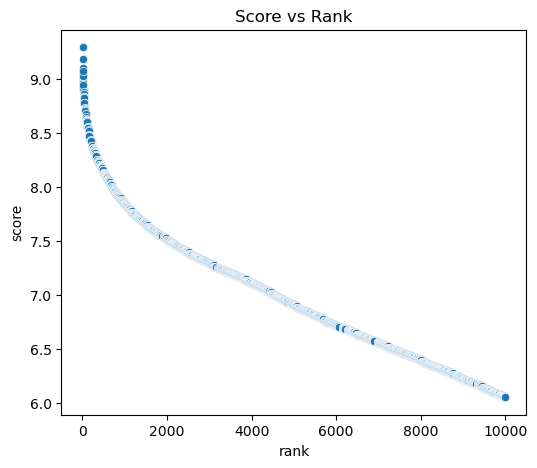

In [19]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="rank", y="score", data=df)
plt.title("Score vs Rank")
plt.show()

Ranking is strongly aligned with rating, confirming internal consistency of the dataset.

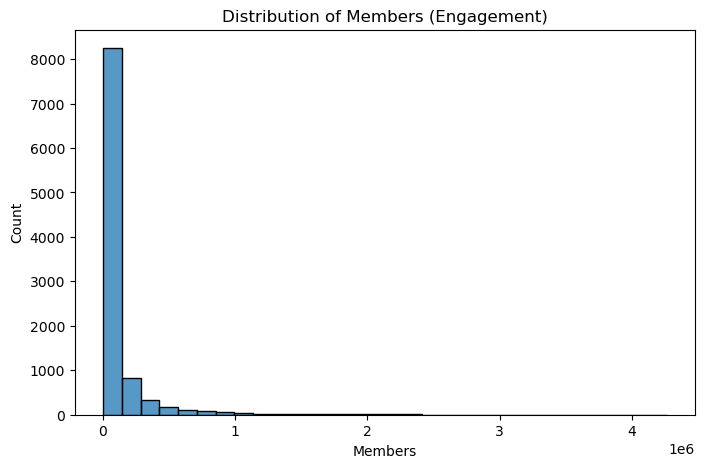

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["members"], bins=30)
plt.title("Distribution of Members (Engagement)")
plt.xlabel("Members")
plt.ylabel("Count")
plt.show()

In [22]:
top_popular = df.sort_values(by="popularity")[["title","score","popularity","members"]].head(10)
top_popular

,title,score,popularity,members
108,Shingeki no Kyojin,8.57,1,4262220
97,Death Note,8.62,2,4202843
10,Fullmetal Alchemist: Brotherhood,9.10,3,3602700
153,One Punch Man,8.48,4,3455995
200,Kimetsu no Yaiba,8.42,5,3356703
3350,Sword Art Online,7.22,6,3249073
1023,Boku no Hero Academia,7.83,7,3236189
2,Hunter x Hunter (2011),9.03,8,3107455
660,Naruto,8.02,9,3055340
1114,Tokyo Ghoul,7.79,10,3002661


In [23]:
df[["score","members","popularity"]].corr()

,score,members,popularity
score,1.000000,0.436472,-0.590194
members,0.436472,1.000000,-0.452963
popularity,-0.590194,-0.452963,1.000000


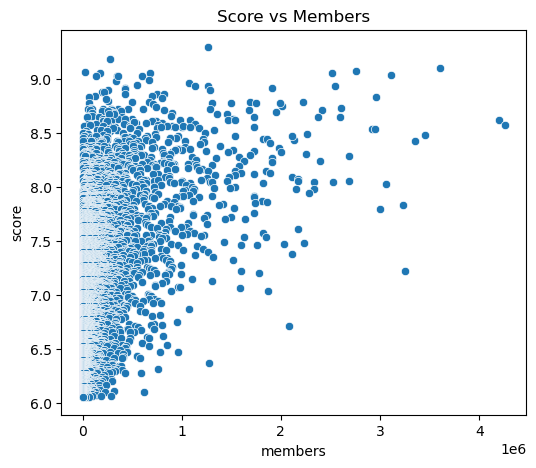

In [24]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="members", y="score", data=df)
plt.title("Score vs Members")
plt.show()

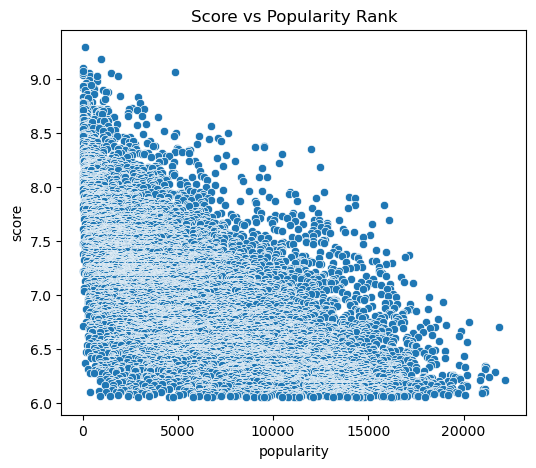

In [25]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="popularity", y="score", data=df)
plt.title("Score vs Popularity Rank")
plt.show()

In [27]:
df["type"].value_counts()

type
TV            4330
Movie         1723
ONA           1339
OVA           1172
Special       1003
TV Special     433
Name: count, dtype: int64

In [28]:
df.groupby("type")["score"].mean().sort_values(ascending=False)

type
TV            7.069148
Movie         7.067319
OVA           6.879889
ONA           6.876706
TV Special    6.788545
Special       6.788544
Name: score, dtype: float64

In [29]:
df.groupby("type")["members"].mean().sort_values(ascending=False)

type
TV            193880.330023
Movie          68131.380151
OVA            39552.224403
TV Special     31427.773672
Special        28088.226321
ONA            22614.362211
Name: members, dtype: float64

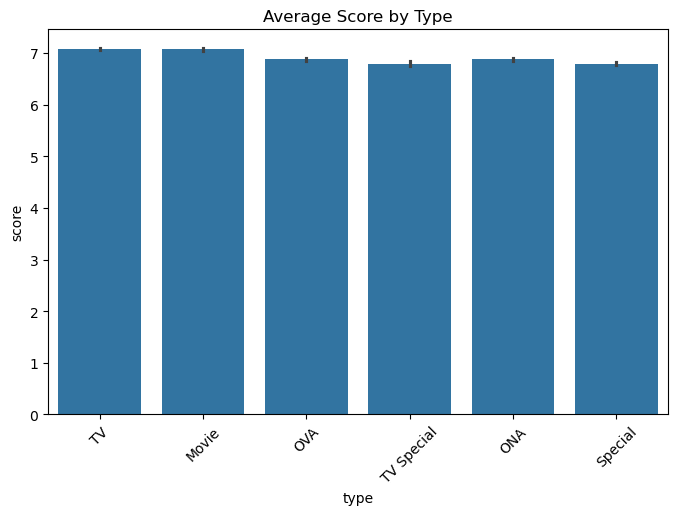

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(x="type", y="score", data=df)
plt.title("Average Score by Type")
plt.xticks(rotation=45)
plt.show()

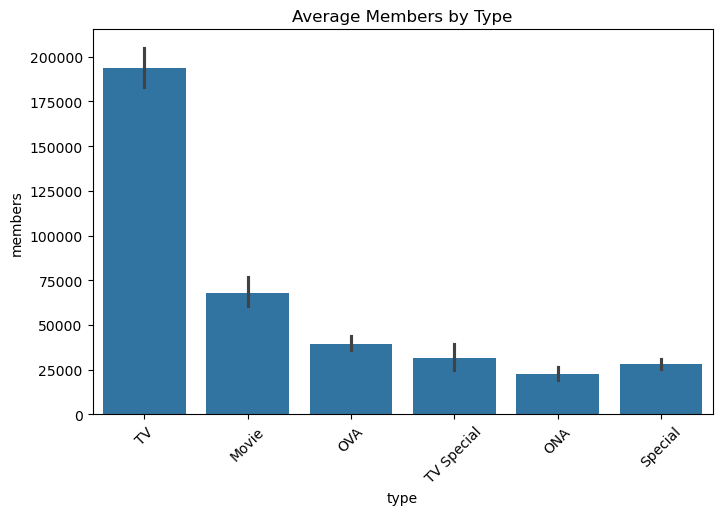

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(x="type", y="members", data=df)
plt.title("Average Members by Type")
plt.xticks(rotation=45)
plt.show()

In [32]:
def episode_category(ep):
    if ep < 12:
        return "Short (<12)"
    elif ep <= 50:
        return "Medium (12-50)"
    else:
        return "Long (>50)"

df["episode_group"] = df["episodes"].apply(episode_category)

In [33]:
df.groupby("episode_group")["score"].mean()

episode_group
Long (>50)        6.958715
Medium (12-50)    7.052059
Short (<12)       6.922236
Name: score, dtype: float64

In [34]:
df.groupby("episode_group")["members"].mean()

episode_group
Long (>50)         89341.798374
Medium (12-50)    172631.055761
Short (<12)        54167.908947
Name: members, dtype: float64

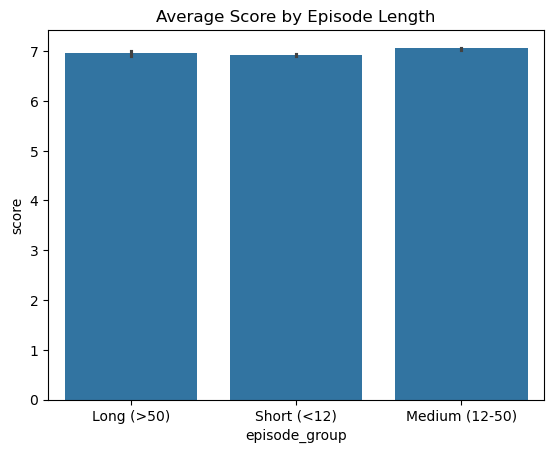

In [35]:
sns.barplot(x="episode_group", y="score", data=df)
plt.title("Average Score by Episode Length")
plt.show()

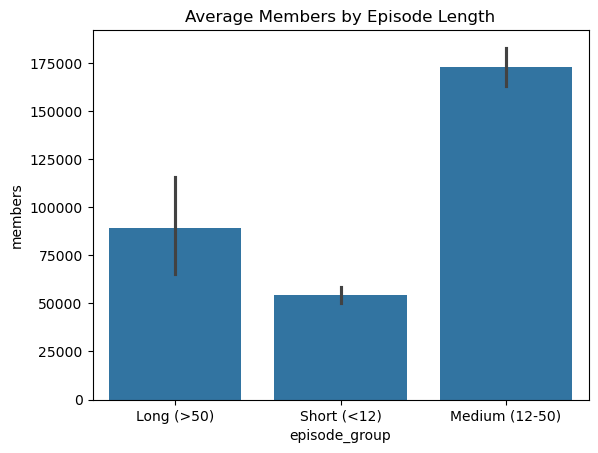

In [36]:
sns.barplot(x="episode_group", y="members", data=df)
plt.title("Average Members by Episode Length")
plt.show()

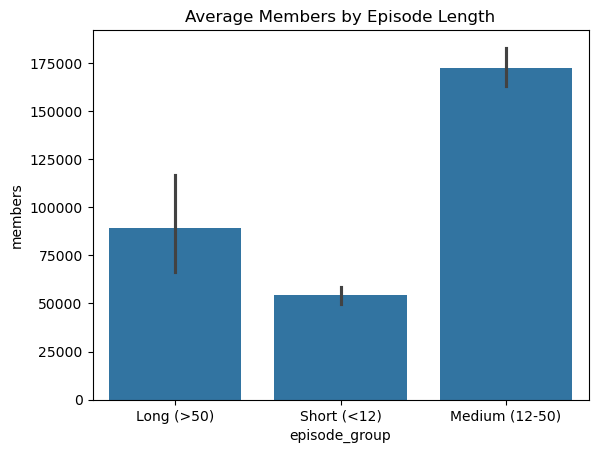

In [37]:
sns.barplot(x="episode_group", y="members", data=df)
plt.title("Average Members by Episode Length")
plt.show()

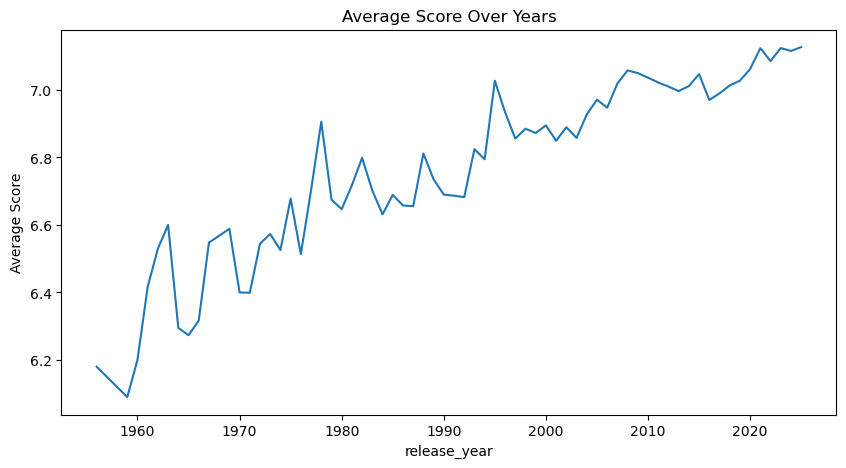

In [38]:
yearly_score = df.groupby("release_year")["score"].mean()

plt.figure(figsize=(10,5))
yearly_score.plot()
plt.title("Average Score Over Years")
plt.ylabel("Average Score")
plt.show()

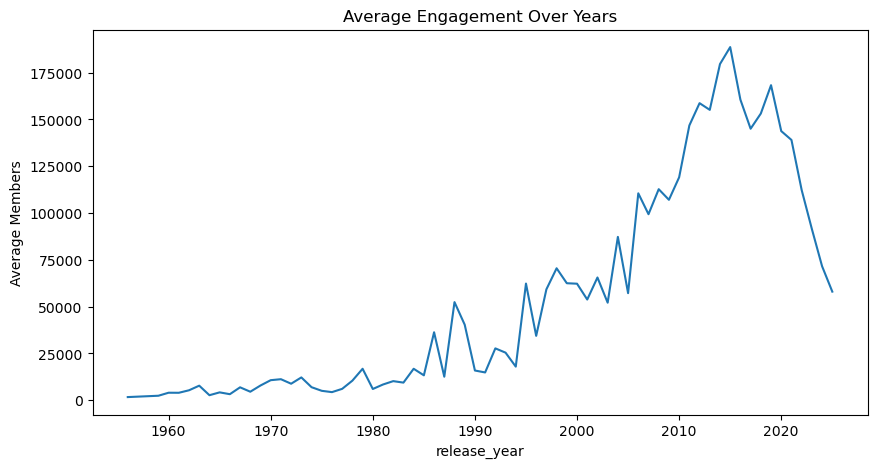

In [39]:
yearly_members = df.groupby("release_year")["members"].mean()

plt.figure(figsize=(10,5))
yearly_members.plot()
plt.title("Average Engagement Over Years")
plt.ylabel("Average Members")
plt.show()

In [40]:
df["is_ongoing"].value_counts()

is_ongoing
0    9916
1      84
Name: count, dtype: int64

In [41]:
df.groupby("is_ongoing")["score"].mean()
df.groupby("is_ongoing")["members"].mean()

is_ongoing
0    108021.477007
1     49616.500000
Name: members, dtype: float64

In [42]:
df.to_csv("anime_cleaned.csv", index=False)